In [10]:
import pandas as pd



In [11]:
df=pd.read_csv('/content/boston.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


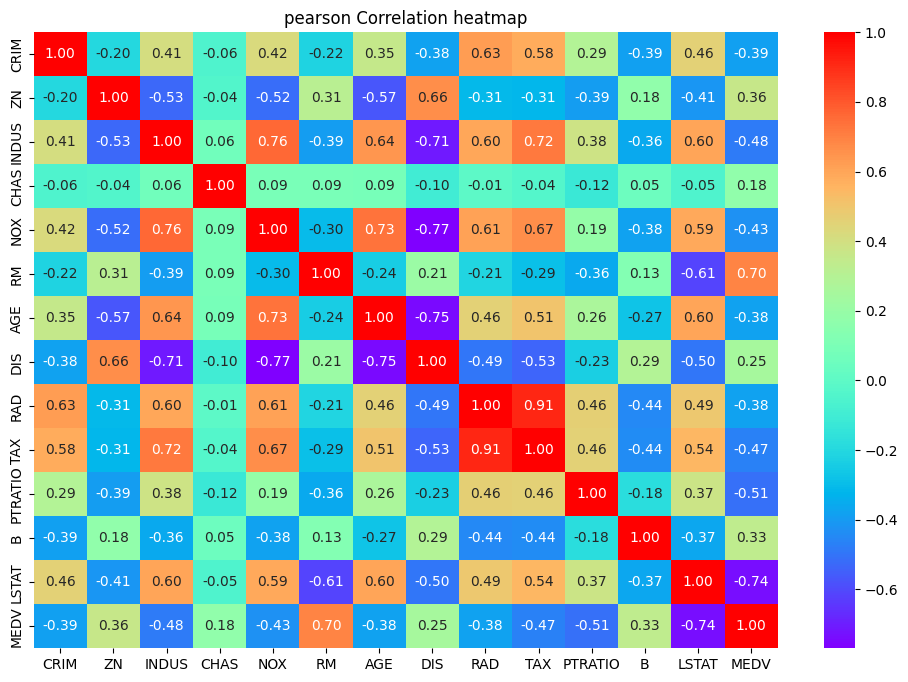

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
#compute correlation matrix
corr_matrix=df.corr()
#heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap='rainbow',fmt=".2f")#cmap='coolwarm'
plt.title("pearson Correlation heatmap")
plt.show()

In [16]:
corr_with_target = corr_matrix['MEDV'].sort_values(ascending=False)
print(corr_with_target)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [18]:
high_corr_features = corr_with_target[abs(corr_with_target)>0.5]
print(high_corr_features)

MEDV       1.000000
RM         0.695360
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [28]:
def remove_outliers(df,columns):
  for col in columns:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df=df[(df[col]>=lower)&(df[col]<=upper)]
  return df

In [29]:
important_cols = high_corr_features.index.tolist()
important_cols.remove('MEDV')

df_clean = remove_outliers(df, important_cols)

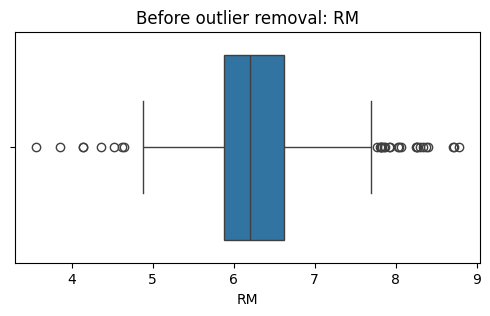

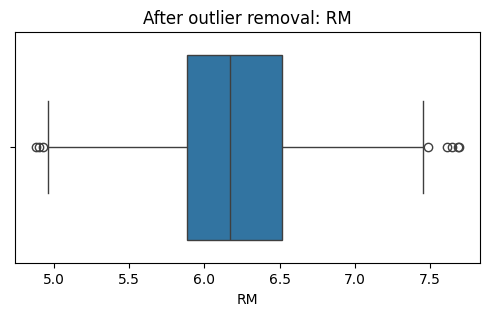

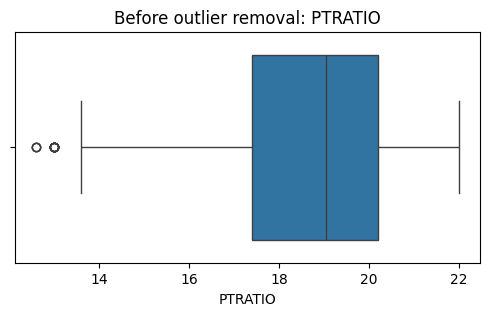

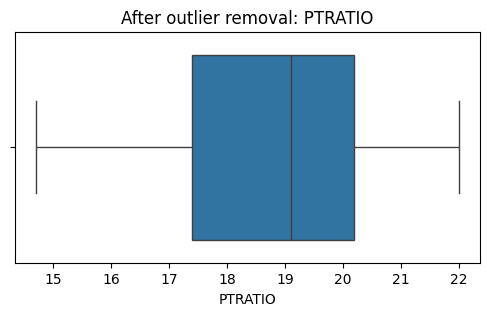

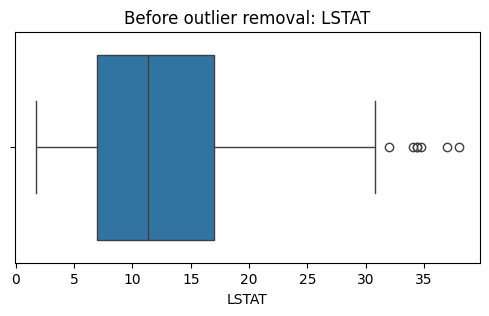

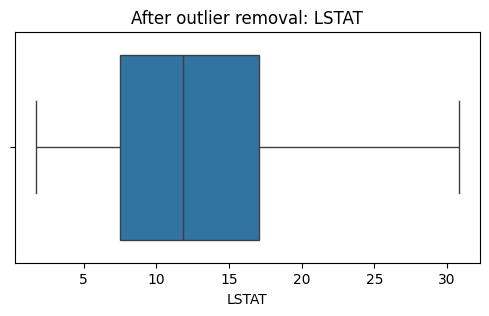

In [30]:
for col in important_cols:
   plt.figure(figsize=(6,3))
   sns.boxplot(x=df[col])
   plt.title(f"Before outlier removal: {col}")
   plt.show()

   plt.figure(figsize=(6,3))
   sns.boxplot(x=df_clean[col])
   plt.title(f"After outlier removal: {col}")
   plt.show()

In [31]:
x = df_clean.drop('MEDV',axis=1)
y = df_clean['MEDV']